In [1]:
import numpy as np
import gmsh
import pyvista
import matplotlib.pyplot as plt
import ufl

from mpi4py import MPI
from petsc4py import PETSc

from dolfinx import fem, default_scalar_type
from dolfinx.io import gmshio
from dolfinx.fem import (
    Function,
    Constant,
    Expression,
    functionspace,
    dirichletbc,
    locate_dofs_topological
)
from dolfinx.fem.petsc import LinearProblem
from dolfinx.mesh import locate_entities_boundary
from dolfinx.plot import vtk_mesh
from dolfinx.mesh import locate_entities, meshtags

from ufl import (
    SpatialCoordinate,
    TrialFunction,
    TestFunction,
    grad,
    dot,
    as_vector
)

In [2]:
# Corrente inicial
I = 1.0  # A

# Constantes
mu0 = 4 * np.pi * 1e-7
g = 9.81

# Núcleo
r_core = 0.75e-2   # m
z_core = 6.0e-2    # m
mu_core = 1200     # permeabilidade relativa

# Esfera
x_gap = 0.5e-2     # m
r_sph = 1.0e-2     # m
m_sph = 22.0e-3    # kg
mu_sph = 1200      # permeabilidade relativa

# Bobina
z_coil = 4.0e-2    # m
N = 200

# Fio AWG
class AWG:
    def __init__(self, tipo):
        self.AWG = tipo
        self.diameter = 0.127e-3 * 92 ** ((36 - tipo) / 39)
        self.area = np.pi * self.diameter**2 / 4
        self.sigma = 58.0e6  # S/m, cobre

awg = AWG(18)

# Espessura radial equivalente da bobina
Coil_thickness = N * awg.area / z_coil

# Raio externo da bobina
r_coil = r_core + Coil_thickness

# Caixa de ar
r_air = 5 * r_coil
z_air = 2.5 * z_core

# Peso da esfera
peso = m_sph * g

print("Coil_thickness =", Coil_thickness, "m")
print("r_coil =", r_coil, "m")
print("peso =", peso, "N")

Coil_thickness = 0.004115234168656572 m
r_coil = 0.011615234168656572 m
peso = 0.21582 N


In [3]:
A_bobina = Coil_thickness * z_coil
J_value = N * I / A_bobina

print("Área equivalente da bobina =", A_bobina, "m²")
print("Densidade de corrente J =", J_value, "A/m²")
print("Conferência I/A_fio =", I / awg.area, "A/m²")

Área equivalente da bobina = 0.00016460936674626288 m²
Densidade de corrente J = 1214997.6878793903 A/m²
Conferência I/A_fio = 1214997.6878793903 A/m²


In [4]:
rank = MPI.COMM_WORLD.rank
gdim = 2

def geometria(x_gap):
    gmsh.initialize()
    gmsh.model.add("levitador_magnetico")

    model_rank = 0
    mesh_comm = MPI.COMM_WORLD

    if mesh_comm.rank == model_rank:

        # Tags físicas
        core_tag = 1
        coil_tag = 2
        sph_tag = 3
        air_tag = 4

        holes = []

        # Ar
        air_rectangle = gmsh.model.occ.addRectangle(
            0, -z_air / 2, 0,
            r_air, z_air
        )
        gmsh.model.occ.synchronize()

        # Núcleo
        core_rectangle = gmsh.model.occ.addRectangle(
            0, 0, 0,
            r_core, z_core
        )
        gmsh.model.occ.synchronize()
        holes.append((gdim, core_rectangle))

        # Bobina centralizada verticalmente no núcleo
        z_coil_ini = (z_core - z_coil) / 2

        coil_rectangle = gmsh.model.occ.addRectangle(
            r_core, z_coil_ini, 0,
            Coil_thickness, z_coil
        )
        gmsh.model.occ.synchronize()
        holes.append((gdim, coil_rectangle))

        # Esfera semicircular à direita do eixo r = 0
        # Topo da esfera em z = -x_gap
        # Centro da esfera em z = -x_gap - r_sph
        z_sph_center = -x_gap - r_sph

        p_top = gmsh.model.occ.addPoint(0, z_sph_center + r_sph, 0)
        p_center = gmsh.model.occ.addPoint(0, z_sph_center, 0)
        p_bottom = gmsh.model.occ.addPoint(0, z_sph_center - r_sph, 0)
        p_right = gmsh.model.occ.addPoint(r_sph, z_sph_center, 0)

        arc_top = gmsh.model.occ.addCircleArc(p_top, p_center, p_right)
        arc_bottom = gmsh.model.occ.addCircleArc(p_right, p_center, p_bottom)
        line_axis = gmsh.model.occ.addLine(p_bottom, p_top)

        curve_loop = gmsh.model.occ.addCurveLoop([arc_top, arc_bottom, line_axis])
        magnetic_sphere = gmsh.model.occ.addPlaneSurface([curve_loop])

        gmsh.model.occ.synchronize()
        holes.append((gdim, magnetic_sphere))

        # Fragmenta todos os domínios
        gmsh.model.occ.fragment([(gdim, air_rectangle)], holes)
        gmsh.model.occ.synchronize()

        # Identifica as superfícies reais depois do fragment
        core_surfaces = []
        coil_surfaces = []
        sphere_surfaces = []
        air_surfaces = []

        for dim, tag in gmsh.model.getEntities(gdim):
            cx, cy, cz = gmsh.model.occ.getCenterOfMass(dim, tag)

            # Núcleo
            if (0 <= cx <= r_core) and (0 <= cy <= z_core):
                core_surfaces.append(tag)

            # Bobina
            elif (r_core <= cx <= r_coil) and (z_coil_ini <= cy <= z_coil_ini + z_coil):
                coil_surfaces.append(tag)

            # Esfera
            elif (0 <= cx <= r_sph) and ((cx**2 + (cy - z_sph_center)**2) <= 1.05 * r_sph**2) and (cy < 0):
                sphere_surfaces.append(tag)

            # Ar
            else:
                air_surfaces.append(tag)

        # Grupos físicos
        gmsh.model.addPhysicalGroup(gdim, core_surfaces, tag=core_tag, name="core")
        gmsh.model.addPhysicalGroup(gdim, coil_surfaces, tag=coil_tag, name="coil")
        gmsh.model.addPhysicalGroup(gdim, sphere_surfaces, tag=sph_tag, name="sphere")
        gmsh.model.addPhysicalGroup(gdim, air_surfaces, tag=air_tag, name="air")

        print("Superfícies núcleo:", core_surfaces)
        print("Superfícies bobina:", coil_surfaces)
        print("Superfícies esfera:", sphere_surfaces)
        print("Superfícies ar:", air_surfaces)

        # Malha
        gmsh.option.setNumber("Mesh.CharacteristicLengthMax", r_core / 8)
        gmsh.model.mesh.generate(gdim)

    mesh, cell_tags, facet_tags = gmshio.model_to_mesh(
        gmsh.model,
        mesh_comm,
        model_rank,
        gdim=gdim
    )

    gmsh.finalize()

    return mesh, cell_tags, facet_tags


mesh, cell_tags, facet_tags = geometria(x_gap)

Superfícies núcleo: [2]nts                                                                                                          
Superfícies bobina: [3]
Superfícies esfera: [4]
Superfícies ar: [5]
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 12 (Line)
Info    : [ 10%] Meshing curve 13 (Line)
Info    : [ 20%] Meshing curve 14 (Circle)
Info    : [ 20%] Meshing curve 15 (Circle)
Info    : [ 30%] Meshing curve 16 (Line)
Info    : [ 30%] Meshing curve 17 (Line)
Info    : [ 40%] Meshing curve 18 (Line)
Info    : [ 40%] Meshing curve 19 (Line)
Info    : [ 50%] Meshing curve 20 (Line)
Info    : [ 60%] Meshing curve 21 (Line)
Info    : [ 60%] Meshing curve 22 (Line)
Info    : [ 70%] Meshing curve 23 (Line)
Info    : [ 70%] Meshing curve 24 (Line)
Info    : [ 80%] Meshing curve 25 (Line)
Info    : [ 80%] Meshing curve 26 (Line)
Info    : [ 90%] Meshing curve 27 (Line)
Info    : [ 90%] Meshing curve 28 (Line)
Info    : [100%] Meshing curve 29 (Line)
Info    : Done meshing 1D (Wall 0

In [5]:
print("core cells =", len(cell_tags.find(1)))
print("coil cells =", len(cell_tags.find(2)))
print("sphere cells =", len(cell_tags.find(3)))
print("air cells =", len(cell_tags.find(4)))

core cells = 1197
coil cells = 456
sphere cells = 452
air cells = 21737


In [6]:
print("Tags presentes na malha:")
print(np.unique(cell_tags.values, return_counts=True))

Tags presentes na malha:
(array([1, 2, 3, 4], dtype=int32), array([ 1197,   456,   452, 21737]))


error: XDG_RUNTIME_DIR is invalid or not set in the environment.
MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


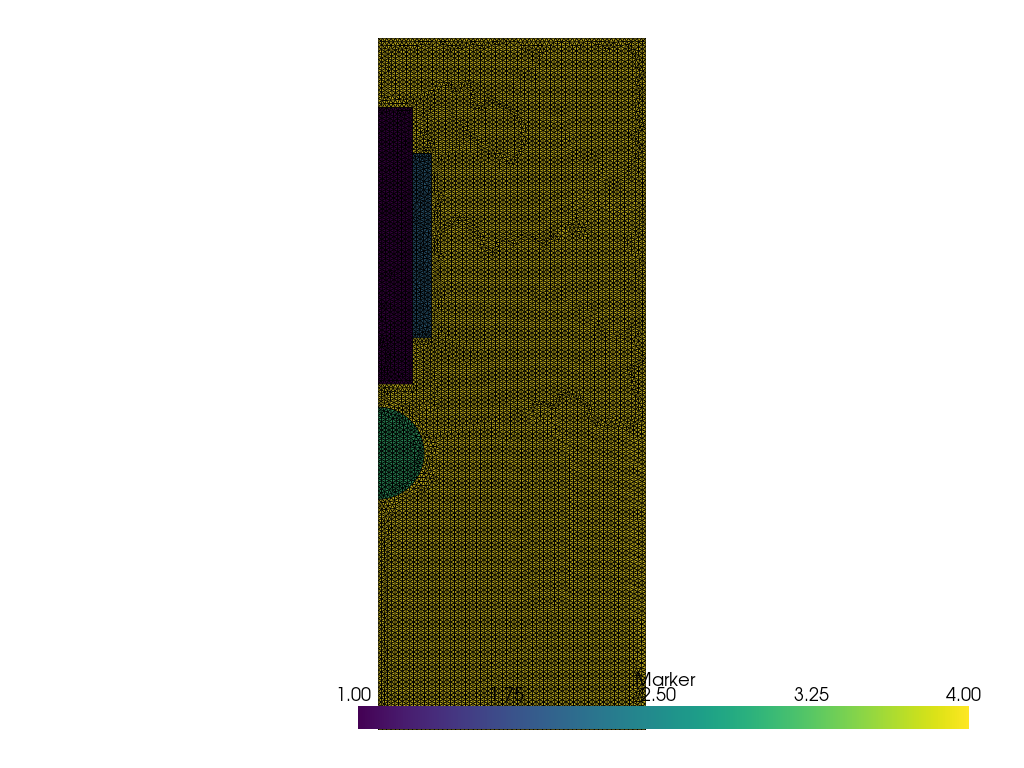

In [7]:
pyvista.start_xvfb()

grid = pyvista.UnstructuredGrid(*vtk_mesh(mesh, mesh.topology.dim))

num_cells = mesh.topology.index_map(mesh.topology.dim).size_local
grid.cell_data["Marker"] = cell_tags.values[cell_tags.indices < num_cells]

plotter = pyvista.Plotter()
plotter.add_mesh(grid, show_edges=True, scalars="Marker")
plotter.view_xy()
plotter.show()

In [8]:
def solve_magnetostatic(mesh, cell_tags, I):
    # Espaço de funções para A' = r A_alpha
    V = functionspace(mesh, ("Lagrange", 2))

    # Coordenada radial
    x = SpatialCoordinate(mesh)
    r = x[0]

    # Espaço DG0 para propriedades constantes por elemento
    Q = functionspace(mesh, ("DG", 0))

    mur = Function(Q)
    J = Function(Q)

    # Tags dos elementos
    core_cells = cell_tags.find(1)
    coil_cells = cell_tags.find(2)
    sphere_cells = cell_tags.find(3)
    air_cells = cell_tags.find(4)

    # Inicializa tudo como ar/cobre
    mur.x.array[:] = 1.0
    J.x.array[:] = 0.0

    # Permeabilidade relativa
    mur.x.array[air_cells] = 1.0
    mur.x.array[coil_cells] = 1.0
    mur.x.array[core_cells] = mu_core
    mur.x.array[sphere_cells] = mu_sph

    # Densidade de corrente na bobina
    A_bobina = Coil_thickness * z_coil
    J_value = N * I / A_bobina
    J.x.array[coil_cells] = J_value

    mur.x.scatter_forward()
    J.x.scatter_forward()

    # Condição de contorno: A' = 0 na fronteira externa
    facets = locate_entities_boundary(
        mesh,
        mesh.topology.dim - 1,
        lambda x: np.full(x.shape[1], True)
    )

    dofs = locate_dofs_topological(
        V,
        mesh.topology.dim - 1,
        facets
    )

    bc = dirichletbc(default_scalar_type(0.0), dofs, V)

    # Funções trial e peso
    A_trial = TrialFunction(V)
    w = TestFunction(V)

    dx = ufl.Measure("dx", domain=mesh, subdomain_data=cell_tags)

    # Forma fraca usando mur relativo:
    # ∫ (1/(mur*r)) grad(A').grad(w) dΩ = ∫ mu0*J*w dΩ
    a = (1.0 / mur) * (1.0 / r) * dot(grad(A_trial), grad(w)) * dx
    L = mu0 * J * w * dx

    A_ = Function(V)

    problem = LinearProblem(a, L, u=A_, bcs=[bc])
    problem.solve()

    return A_, V, mur, J, r, dx, J_value

In [9]:
A_, V, mur, J, r, dx, J_value = solve_magnetostatic(mesh, cell_tags, I)

print("Problema resolvido para I =", I, "A")
print("Densidade de corrente J =", J_value, "A/m²")
print("A' mínimo =", np.min(A_.x.array))
print("A' máximo =", np.max(A_.x.array))

Problema resolvido para I = 1.0 A
Densidade de corrente J = 1214997.6878793903 A/m²
A' mínimo = 0.0
A' máximo = 2.2982092370086086e-06


error: XDG_RUNTIME_DIR is invalid or not set in the environment.
MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


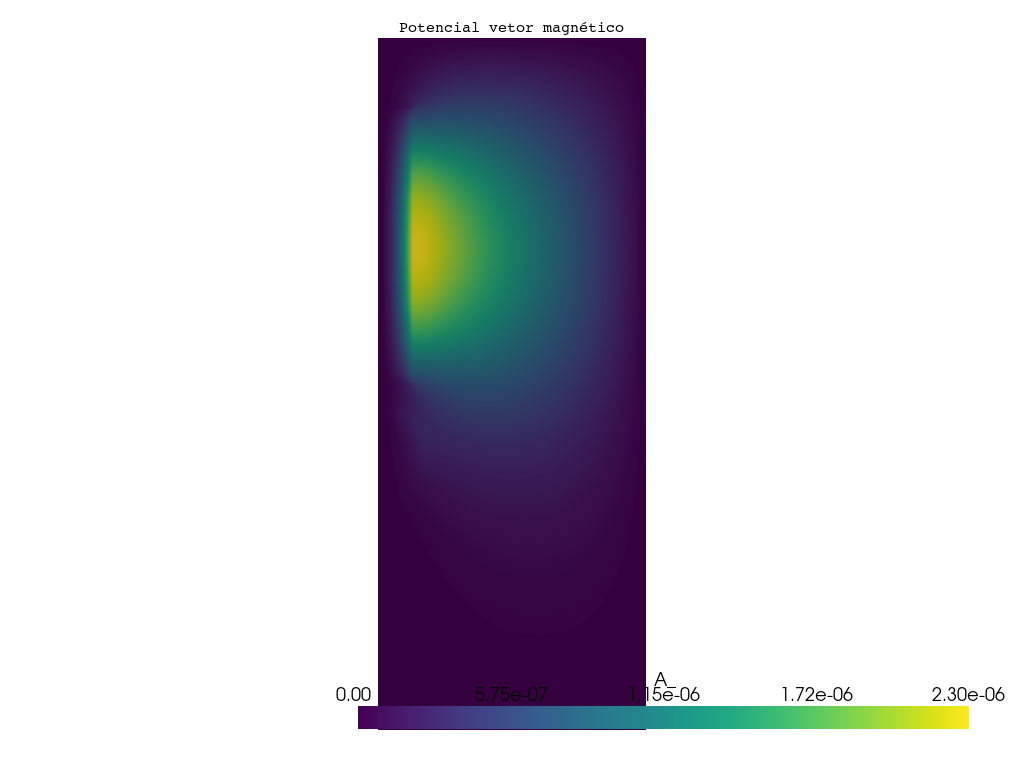

In [10]:
pyvista.start_xvfb()

plotter = pyvista.Plotter()

A_grid = pyvista.UnstructuredGrid(*vtk_mesh(V))
A_grid.point_data["A_"] = A_.x.array.real
A_grid.set_active_scalars("A_")

warp = A_grid.warp_by_scalar("A_")

plotter.add_mesh(warp, show_edges=False)
plotter.view_xy()

plotter.add_title(
    "Potencial vetor magnético",
    font="courier",
    color="k",
    font_size=7
)

plotter.show()

In [11]:
def calc_B_H(mesh, A_, r, mur):
    # Espaço DG0 vetorial
    W = functionspace(mesh, ("DG", 0, (mesh.geometry.dim, )))

    # B = curl(A)
    B = Function(W)
    B_expr = Expression(
        as_vector((
            -(1.0 / r) * A_.dx(1),
             (1.0 / r) * A_.dx(0)
        )),
        W.element.interpolation_points()
    )
    B.interpolate(B_expr)

    # H = B / (mu0*mur)
    H = Function(W)
    H_expr = Expression(
        as_vector((
            -(1.0 / (mu0 * mur * r)) * A_.dx(1),
             (1.0 / (mu0 * mur * r)) * A_.dx(0)
        )),
        W.element.interpolation_points()
    )
    H.interpolate(H_expr)

    return B, H, W

In [12]:
B, H, W = calc_B_H(mesh, A_, r, mur)

In [13]:
B_values = B.x.array.real.reshape((-1, mesh.geometry.dim))
H_values = H.x.array.real.reshape((-1, mesh.geometry.dim))

B_norm = np.linalg.norm(B_values, axis=1)
H_norm = np.linalg.norm(H_values, axis=1)

print("B mínimo =", np.min(B_norm), "T")
print("B máximo =", np.max(B_norm), "T")
print("H mínimo =", np.min(H_norm), "A/m")
print("H máximo =", np.max(H_norm), "A/m")

B mínimo = 7.800745942342525e-07 T
B máximo = 0.08255108265806951 T
H mínimo = 0.6207636382639291 A/m
H máximo = 16160.659860680937 A/m


error: XDG_RUNTIME_DIR is invalid or not set in the environment.
MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


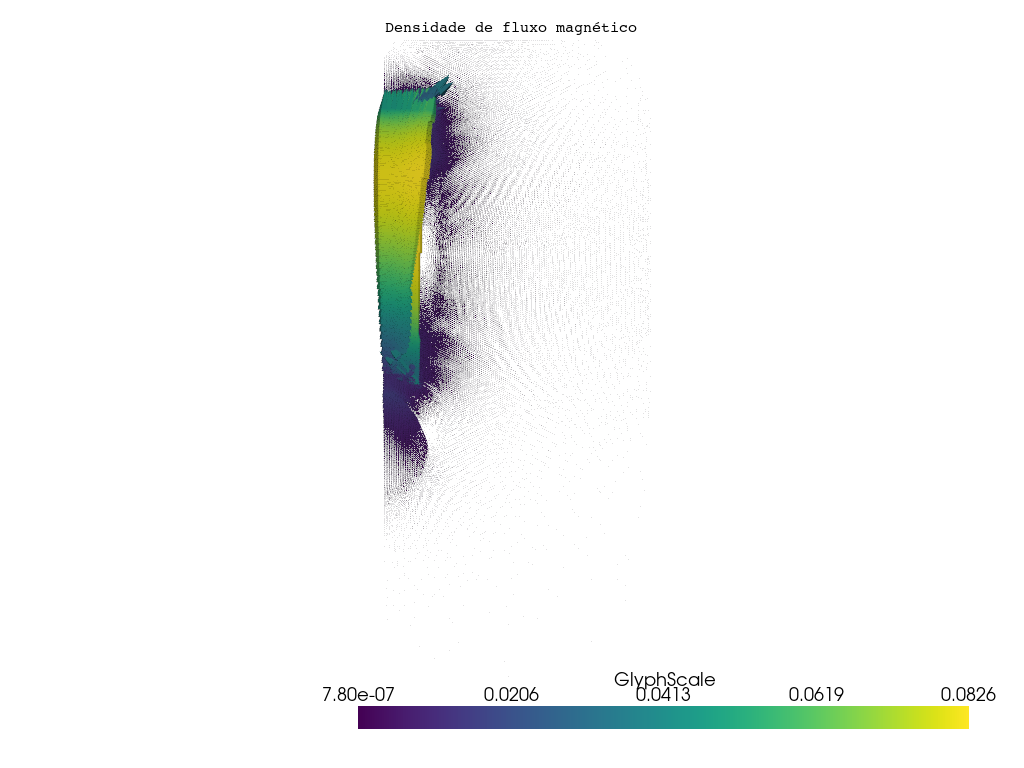

In [14]:
# Interpola B novamente para coincidir com os graus de liberdade da malha VTK
Wl = functionspace(mesh, ("Lagrange", 2, (mesh.geometry.dim, )))
Bl = Function(Wl)
Bl.interpolate(B)

pyvista.start_xvfb()

topology, cell_types, geo = vtk_mesh(V)

values = np.zeros((geo.shape[0], 3), dtype=np.float64)
values[:, :mesh.geometry.dim] = Bl.x.array.real.reshape((geo.shape[0], mesh.geometry.dim))

# Cria uma malha para representar os vetores do campo
function_grid = pyvista.UnstructuredGrid(topology, cell_types, geo)
function_grid["Bl"] = values
function_grid.set_active_vectors("Bl")

# Cria os vetores do campo B
glyphs = function_grid.glyph(orient="Bl", factor=0.3)

# Cria a malha do domínio
mesh.topology.create_connectivity(mesh.topology.dim, mesh.topology.dim)
grid = pyvista.UnstructuredGrid(*vtk_mesh(mesh, mesh.topology.dim))

# Plota o campo vetorial
plotter = pyvista.Plotter()

plotter.add_mesh(glyphs)
plotter.view_xy()

plotter.add_title(
    "Densidade de fluxo magnético",
    font="courier",
    color="k",
    font_size=7
)

plotter.show()

error: XDG_RUNTIME_DIR is invalid or not set in the environment.
MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


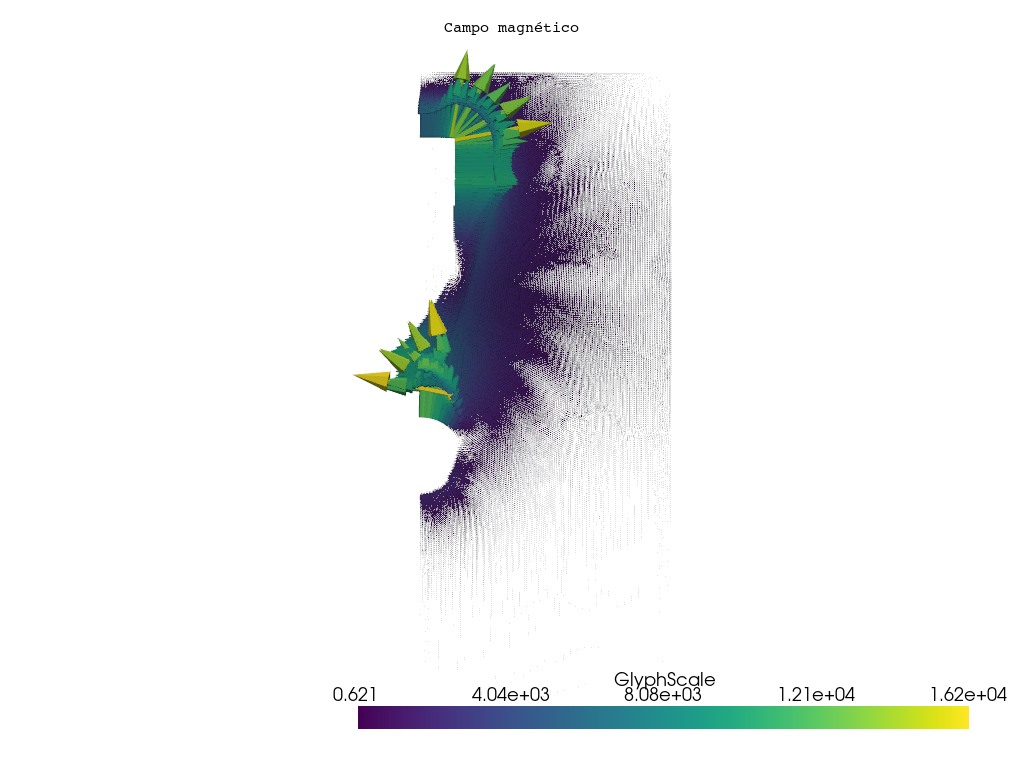

In [15]:
# Interpola H novamente para coincidir com os graus de liberdade da malha VTK
Wl = functionspace(mesh, ("Lagrange", 2, (mesh.geometry.dim, )))
Hl = Function(Wl)
Hl.interpolate(H)

pyvista.start_xvfb()

topology, cell_types, geo = vtk_mesh(V)

values = np.zeros((geo.shape[0], 3), dtype=np.float64)
values[:, :mesh.geometry.dim] = Hl.x.array.real.reshape((geo.shape[0], mesh.geometry.dim))

# Cria uma malha para representar os vetores do campo
function_grid = pyvista.UnstructuredGrid(topology, cell_types, geo)
function_grid["Hl"] = values
function_grid.set_active_vectors("Hl")

# Cria os vetores do campo H
glyphs = function_grid.glyph(orient="Hl", factor=1.5e-6)

# Cria a malha do domínio
mesh.topology.create_connectivity(mesh.topology.dim, mesh.topology.dim)
grid = pyvista.UnstructuredGrid(*vtk_mesh(mesh, mesh.topology.dim))

# Plota o campo vetorial
plotter = pyvista.Plotter()

plotter.add_mesh(glyphs)
plotter.view_xy()

plotter.add_title(
    "Campo magnético",
    font="courier",
    color="k",
    font_size=7
)

plotter.show()

In [16]:
from dolfinx import geometry

def avaliar_H_superficie_esfera(mesh, H, x_gap, n_pontos=200):
    # Centro da esfera
    z_sph_center = -x_gap - r_sph

    # Evita exatamente os pontos do eixo r = 0
    theta = np.linspace(-np.pi/2 + 1e-3, np.pi/2 - 1e-3, n_pontos)

    # Pontos exatamente na superfície da esfera
    r_surf = r_sph * np.cos(theta)
    z_surf = z_sph_center + r_sph * np.sin(theta)

    # Vetor normal externo da esfera
    nr = np.cos(theta)
    nz = np.sin(theta)

    # Avalia o campo um pouco fora da esfera, no ar
    eps = 0.02 * r_sph
    r_eval = r_surf + eps * nr
    z_eval = z_surf + eps * nz

    points = np.zeros((n_pontos, 3), dtype=np.float64)
    points[:, 0] = r_eval
    points[:, 1] = z_eval

    # Encontra as células que contêm os pontos de avaliação
    bb_tree = geometry.bb_tree(mesh, mesh.topology.dim)
    cell_candidates = geometry.compute_collisions_points(bb_tree, points)
    colliding_cells = geometry.compute_colliding_cells(mesh, cell_candidates, points)

    cells = []
    valid_points = []
    valid_indices = []

    for i, point in enumerate(points):
        links = colliding_cells.links(i)

        if len(links) > 0:
            valid_points.append(point)
            cells.append(links[0])
            valid_indices.append(i)

    valid_points = np.array(valid_points, dtype=np.float64)
    cells = np.array(cells, dtype=np.int32)
    valid_indices = np.array(valid_indices, dtype=np.int32)

    # Avalia H nos pontos encontrados
    H_values = H.eval(valid_points, cells)

    Hr = H_values[:, 0]
    Hz = H_values[:, 1]

    return (
        theta[valid_indices],
        r_surf[valid_indices],
        z_surf[valid_indices],
        Hr,
        Hz,
        nr[valid_indices],
        nz[valid_indices]
    )

In [17]:
theta_s, r_s, z_s, Hr_s, Hz_s, nr_s, nz_s = avaliar_H_superficie_esfera(mesh, H, x_gap)

print("Número de pontos avaliados:", len(theta_s))
print("Hr mínimo =", np.min(Hr_s))
print("Hr máximo =", np.max(Hr_s))
print("Hz mínimo =", np.min(Hz_s))
print("Hz máximo =", np.max(Hz_s))

Número de pontos avaliados: 200
Hr mínimo = -1792.604402333715
Hr máximo = 3204.7499363265083
Hz mínimo = -148.36297780336426
Hz máximo = 12361.68730009554


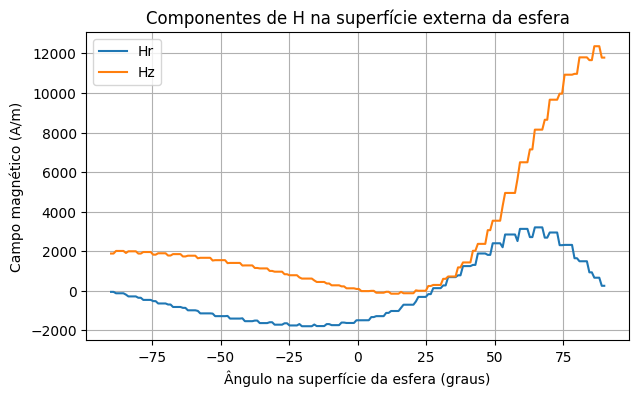

In [18]:
theta_graus = np.degrees(theta_s)

plt.figure(figsize=(7, 4))

plt.plot(theta_graus, Hr_s, label="Hr")
plt.plot(theta_graus, Hz_s, label="Hz")

plt.xlabel("Ângulo na superfície da esfera (graus)")
plt.ylabel("Campo magnético (A/m)")
plt.title("Componentes de H na superfície externa da esfera")
plt.grid(True)
plt.legend()

plt.show()

In [19]:
def calcular_forca_maxwell(theta, r_surf, Hr, Hz, nr, nz):
    H2 = Hr**2 + Hz**2
    Hn = Hr * nr + Hz * nz

    # Componente z do tensor de Maxwell
    tz = -0.5 * mu0 * H2 * nz + mu0 * Hn * Hz

    # Integral axissimétrica: dS = 2*pi*r*ds
    integrando = 2 * np.pi * r_surf * tz * r_sph

    Fz = np.trapz(integrando, theta)

    return Fz


Fz_manual = calcular_forca_maxwell(theta_s, r_s, Hr_s, Hz_s, nr_s, nz_s)

print("Força magnética manual =", Fz_manual, "N")
print("Peso da esfera =", peso, "N")
print("Razão Fz_manual/peso =", Fz_manual / peso)

Força magnética manual = 0.0054570683852614935 N
Peso da esfera = 0.21582 N
Razão Fz_manual/peso = 0.025285276551114323


In [20]:
from dolfinx.mesh import locate_entities, meshtags

# Marca a superfície externa da esfera para integração
fdim = mesh.topology.dim - 1
z_sph_center = -x_gap - r_sph

def on_sphere_surface(x):
    raio = np.sqrt(x[0]**2 + (x[1] - z_sph_center)**2)

    return np.logical_and(
        np.isclose(raio, r_sph, atol=1e-4),
        x[0] > 1e-6
    )

sphere_facets = locate_entities(
    mesh,
    fdim,
    on_sphere_surface
)

facet_markers = np.ones(len(sphere_facets), dtype=np.int32)

facet_tag = meshtags(
    mesh,
    fdim,
    sphere_facets,
    facet_markers
)

dS_sphere = ufl.Measure(
    "dS",
    domain=mesh,
    subdomain_data=facet_tag
)

print("Número de facets na superfície da esfera:", len(sphere_facets))

# Teste do comprimento do arco da esfera
comprimento_arco = fem.assemble_scalar(
    fem.form(1.0 * dS_sphere(1))
)

print("Comprimento do arco da esfera =", comprimento_arco, "m")
print("Valor esperado aproximado =", np.pi * r_sph, "m")

Número de facets na superfície da esfera: 32
Comprimento do arco da esfera = 0.02955741353327334 m
Valor esperado aproximado = 0.031415926535897934 m


In [21]:
# Calcula a força magnética usando FacetNormal() e assemble()

n = ufl.FacetNormal(mesh)

dF_z = fem.form(
    2 * np.pi * mu0 * r *
    (
        -0.5 * (H[0]('-')**2 + H[1]('-')**2) * n[1]('+')
        + dot(H('-'), n('+')) * H[1]('-')
    )
    * dS_sphere(1)
    + Constant(mesh, PETSc.ScalarType(0.0)) * dx
)

Fz_assemble = fem.assemble_scalar(dF_z)

print("Força pelo assemble =", Fz_assemble, "N")
print("Força manual =", Fz_manual, "N")
print("Erro percentual =", 100 * (Fz_assemble - Fz_manual) / Fz_manual, "%")

Força pelo assemble = 0.005864786185601976 N
Força manual = 0.0054570683852614935 N
Erro percentual = 7.471370552028464 %


In [22]:
# Corrente de equilíbrio usando a força calculada com FacetNormal() e assemble()
I_eq = I * np.sqrt(peso / abs(Fz_assemble))

print("Corrente de equilíbrio =", I_eq, "A")

Corrente de equilíbrio = 6.066242289840428 A


In [23]:
# Cálculo da resistência e potência dissipada no fio usando a corrente corrigida

r_medio_bobina = r_core + Coil_thickness / 2
comprimento_fio = N * 2 * np.pi * r_medio_bobina

R_fio = comprimento_fio / (awg.sigma * awg.area)
P_dissipada = R_fio * I_eq**2

print("Corrente de equilíbrio utilizada =", I_eq, "A")
print("Raio médio da bobina =", r_medio_bobina, "m")
print("Comprimento aproximado do fio =", comprimento_fio, "m")
print("Resistência aproximada do fio =", R_fio, "ohm")
print("Potência dissipada =", P_dissipada, "W")
print("Densidade de corrente no fio =", I_eq / awg.area, "A/m²")
print("Densidade de corrente no fio =", I_eq / awg.area / 1e6, "A/mm²")

Corrente de equilíbrio utilizada = 6.066242289840428 A
Raio médio da bobina = 0.009557617084328285 m
Comprimento aproximado do fio = 12.010455847180015 m
Resistência aproximada do fio = 0.2515978635293314 ohm
Potência dissipada = 9.258624131977086 W
Densidade de corrente no fio = 7370470.356272298 A/m²
Densidade de corrente no fio = 7.370470356272298 A/mm²


In [24]:
# PARTE 2

In [25]:
# Pontos para levantamento dos parâmetros concentrados
x_values = np.linspace(0.1 * x_gap, 3.0 * x_gap, 10)

# Corrente corrigida obtida na primeira parte
I_corrigida = I_eq

print("Corrente corrigida =", I_corrigida, "A")
print("Pontos de posição da esfera (m):")
print(x_values)

Corrente corrigida = 6.066242289840428 A
Pontos de posição da esfera (m):
[0.0005     0.00211111 0.00372222 0.00533333 0.00694444 0.00855556
 0.01016667 0.01177778 0.01338889 0.015     ]


In [26]:
# Vetores para armazenar os resultados
Fm_values = np.zeros(len(x_values))
L_values = np.zeros(len(x_values))

Bmax_core_values = np.zeros(len(x_values))
Bmed_core_values = np.zeros(len(x_values))

Bmax_sph_values = np.zeros(len(x_values))
Bmed_sph_values = np.zeros(len(x_values))

In [27]:
for i, x_pos in enumerate(x_values):

    print("Resolvendo posição", i + 1, "de", len(x_values))
    print("x =", x_pos, "m")

    # Gera a geometria para a posição atual
    mesh_i, cell_tags_i, facet_tags_i = geometria(x_pos)

    # Resolve o problema magnetostático
    A_i, V_i, mur_i, J_i, r_i, dx_i, J_value_i = solve_magnetostatic(
        mesh_i,
        cell_tags_i,
        I_corrigida
    )

    # Calcula B e H
    B_i, H_i, W_i = calc_B_H(mesh_i, A_i, r_i, mur_i)

    # Avalia H na superfície externa da esfera
    theta_i, r_s_i, z_s_i, Hr_i, Hz_i, nr_i, nz_i = avaliar_H_superficie_esfera(
        mesh_i,
        H_i,
        x_pos
    )

    # Calcula a força magnética pelo tensor de Maxwell
    Fz_i = calcular_forca_maxwell(
        theta_i,
        r_s_i,
        Hr_i,
        Hz_i,
        nr_i,
        nz_i
    )

    Fm_values[i] = abs(Fz_i)

    # Calcula a energia magnética e a indutância
    # Como mur_i é relativo, a permeabilidade absoluta é mu0*mur_i
    Energy_i = np.pi * fem.assemble_scalar(
        fem.form(r_i / (mu0 * mur_i) * dot(B_i, B_i) * dx_i)
    )

    L_values[i] = 2 * Energy_i / I_corrigida**2

    # Elementos de cada região
    core_elements = cell_tags_i.find(1)
    sph_elements = cell_tags_i.find(3)

    # Norma de B em cada elemento
    B_values = B_i.x.array.real.reshape((-1, mesh_i.geometry.dim))
    norm_B = np.linalg.norm(B_values, axis=1)

    # Valores máximos e médios no núcleo
    Bmax_core_values[i] = np.max(norm_B[core_elements])
    Bmed_core_values[i] = np.mean(norm_B[core_elements])

    # Valores máximos e médios na esfera
    Bmax_sph_values[i] = np.max(norm_B[sph_elements])
    Bmed_sph_values[i] = np.mean(norm_B[sph_elements])

    print("Fm =", Fm_values[i], "N")
    print("L =", L_values[i], "H")
    print("Bmax núcleo =", Bmax_core_values[i], "T")
    print("Bmed núcleo =", Bmed_core_values[i], "T")
    print("Bmax esfera =", Bmax_sph_values[i], "T")
    print("Bmed esfera =", Bmed_sph_values[i], "T")
    print("--------------------------------")

Resolvendo posição 1 de 10
x = 0.0005 m
Superfícies núcleo: [2]nts                                                                                                          
Superfícies bobina: [3]
Superfícies esfera: [4]
Superfícies ar: [5]
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 12 (Line)
Info    : [ 10%] Meshing curve 13 (Line)
Info    : [ 20%] Meshing curve 14 (Circle)
Info    : [ 20%] Meshing curve 15 (Circle)
Info    : [ 30%] Meshing curve 16 (Line)
Info    : [ 30%] Meshing curve 17 (Line)
Info    : [ 40%] Meshing curve 18 (Line)
Info    : [ 40%] Meshing curve 19 (Line)
Info    : [ 50%] Meshing curve 20 (Line)
Info    : [ 60%] Meshing curve 21 (Line)
Info    : [ 60%] Meshing curve 22 (Line)
Info    : [ 70%] Meshing curve 23 (Line)
Info    : [ 70%] Meshing curve 24 (Line)
Info    : [ 80%] Meshing curve 25 (Line)
Info    : [ 80%] Meshing curve 26 (Line)
Info    : [ 90%] Meshing curve 27 (Line)
Info    : [ 90%] Meshing curve 28 (Line)
Info    : [100%] Meshing curve 29 

In [28]:
import pandas as pd

df_parametros = pd.DataFrame({
    "x (mm)": x_values * 1e3,
    "Fm (N)": Fm_values,
    "L (H)": L_values,
    "Bmax núcleo (T)": Bmax_core_values,
    "Bmed núcleo (T)": Bmed_core_values,
    "Bmax esfera (T)": Bmax_sph_values,
    "Bmed esfera (T)": Bmed_sph_values
})

df_parametros

,x (mm),Fm (N),L (H),Bmax núcleo (T),Bmed núcleo (T),Bmax esfera (T),Bmed esfera (T)
0,0.500000,1.764384,0.002650,0.525312,0.383412,0.407647,0.092024
1,2.111111,0.554884,0.002562,0.510333,0.365011,0.164478,0.060053
2,3.722222,0.298516,0.002523,0.503862,0.357714,0.116870,0.046190
3,5.333333,0.182703,0.002502,0.500146,0.353670,0.091462,0.036981
4,6.944444,0.117842,0.002488,0.497827,0.351193,0.073453,0.030790
5,8.555556,0.078175,0.002479,0.496346,0.349604,0.059794,0.025762
6,10.166667,0.053746,0.002473,0.495338,0.348539,0.049131,0.021776
7,11.777778,0.037006,0.002469,0.494639,0.347813,0.040744,0.018554
8,13.388889,0.026271,0.002466,0.494149,0.347309,0.034061,0.015910
9,15.000000,0.019011,0.002464,0.493801,0.346957,0.028683,0.013717


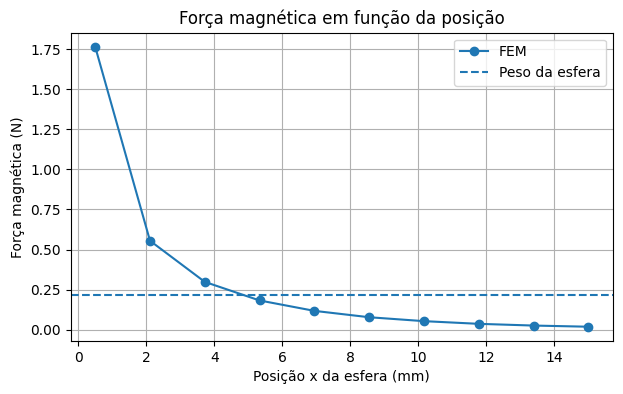

In [29]:
plt.figure(figsize=(7, 4))

plt.plot(x_values * 1e3, Fm_values, marker="o", label="FEM")
plt.axhline(peso, linestyle="--", label="Peso da esfera")

plt.xlabel("Posição x da esfera (mm)")
plt.ylabel("Força magnética (N)")
plt.title("Força magnética em função da posição")
plt.grid(True)
plt.legend()

plt.show()

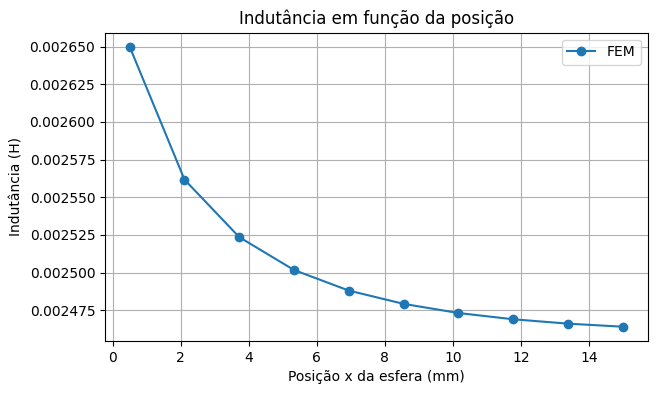

In [30]:
plt.figure(figsize=(7, 4))

plt.plot(x_values * 1e3, L_values, marker="o", label="FEM")

plt.xlabel("Posição x da esfera (mm)")
plt.ylabel("Indutância (H)")
plt.title("Indutância em função da posição")
plt.grid(True)
plt.legend()

plt.show()

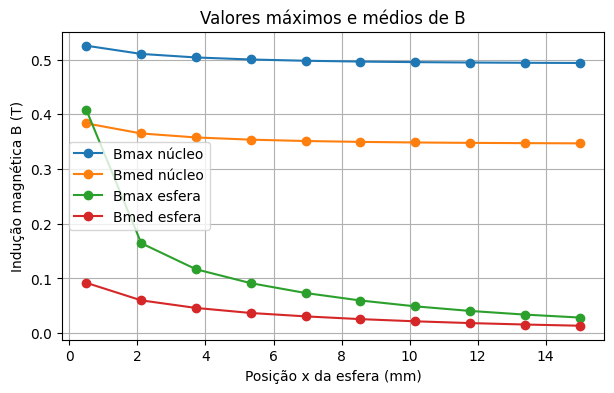

In [31]:
plt.figure(figsize=(7, 4))

plt.plot(x_values * 1e3, Bmax_core_values, marker="o", label="Bmax núcleo")
plt.plot(x_values * 1e3, Bmed_core_values, marker="o", label="Bmed núcleo")
plt.plot(x_values * 1e3, Bmax_sph_values, marker="o", label="Bmax esfera")
plt.plot(x_values * 1e3, Bmed_sph_values, marker="o", label="Bmed esfera")

plt.xlabel("Posição x da esfera (mm)")
plt.ylabel("Indução magnética B (T)")
plt.title("Valores máximos e médios de B")
plt.grid(True)
plt.legend()

plt.show()

Ponto de referência = 0.005333333333333332 m
Ponto de referência = 5.333333333333332 mm
k obtido pela indutância = 1.3342123086670402e-05
k obtido pela força = 2.824452247735481e-07
Razão k_L/k_F = 47.23791346576143


,x (mm),L FEM (H),Fm FEM (N),k_L = xL(x),k_F = 2Fm(x/I)^2,k_L/k_F
0,0.500000,0.002650,1.764384,0.000001,2.397306e-08,55.267353
1,2.111111,0.002562,0.554884,0.000005,1.344048e-07,40.236462
2,3.722222,0.002523,0.298516,0.000009,2.247826e-07,41.786842
3,5.333333,0.002502,0.182703,0.000013,2.824452e-07,47.237913
4,6.944444,0.002488,0.117842,0.000017,3.088635e-07,55.940060
5,8.555556,0.002479,0.078175,0.000021,3.109963e-07,68.203113
6,10.166667,0.002473,0.053746,0.000025,3.019241e-07,83.277570
7,11.777778,0.002469,0.037006,0.000029,2.789913e-07,104.229067
8,13.388889,0.002466,0.026271,0.000033,2.559510e-07,129.001309
9,15.000000,0.002464,0.019011,0.000037,2.324814e-07,158.982804


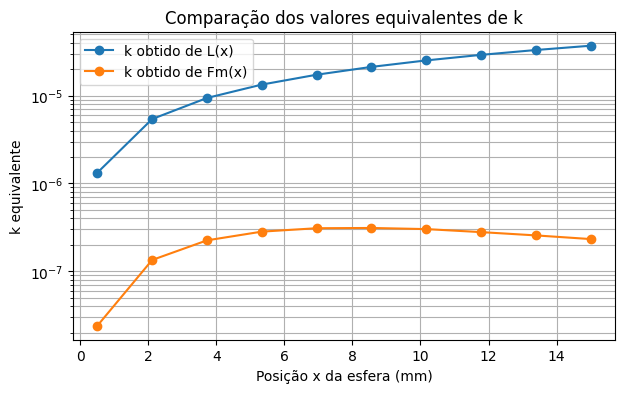

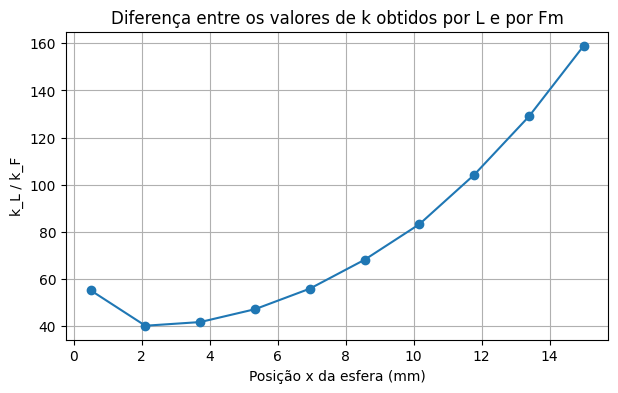

In [32]:
# Comparação com o modelo planar da Aula 18
# Modelo planar:
# L(x) = k/x
# Fm(I,x) = k/2 * (I/x)^2
#
# Reescrevendo:
# k = xL(x)
# k = 2Fm(x/I)^2

k_L_values = L_values * x_values
k_F_values = 2 * Fm_values * (x_values / I_corrigida)**2

idx_ref = np.argmin(np.abs(x_values - x_gap))

print("Ponto de referência =", x_values[idx_ref], "m")
print("Ponto de referência =", x_values[idx_ref] * 1e3, "mm")
print("k obtido pela indutância =", k_L_values[idx_ref])
print("k obtido pela força =", k_F_values[idx_ref])
print("Razão k_L/k_F =", k_L_values[idx_ref] / k_F_values[idx_ref])

df_k = pd.DataFrame({
    "x (mm)": x_values * 1e3,
    "L FEM (H)": L_values,
    "Fm FEM (N)": Fm_values,
    "k_L = xL(x)": k_L_values,
    "k_F = 2Fm(x/I)^2": k_F_values,
    "k_L/k_F": k_L_values / k_F_values
})

display(df_k)

plt.figure(figsize=(7, 4))

plt.semilogy(x_values * 1e3, k_L_values, marker="o", label="k obtido de L(x)")
plt.semilogy(x_values * 1e3, k_F_values, marker="o", label="k obtido de Fm(x)")

plt.xlabel("Posição x da esfera (mm)")
plt.ylabel("k equivalente")
plt.title("Comparação dos valores equivalentes de k")
plt.grid(True, which="both")
plt.legend()

plt.show()

plt.figure(figsize=(7, 4))

plt.plot(x_values * 1e3, k_L_values / k_F_values, marker="o")

plt.xlabel("Posição x da esfera (mm)")
plt.ylabel("k_L / k_F")
plt.title("Diferença entre os valores de k obtidos por L e por Fm")
plt.grid(True)

plt.show()

In [33]:
# PARTE 3

In [34]:
# Efeitos da não linearidade
# Comparação entre a curva B x H do FEMM e a aproximação linear mur = 1200

B_curve = np.array([
    0.000000,
    0.227065,
    0.454130,
    0.681195,
    0.908260,
    1.135330,
    1.362390,
    1.589350,
    1.812360,
    2.010040,
    2.133160,
    2.199990,
    2.254790,
    2.299930,
    2.342510,
    2.378760,
    2.415010,
    2.451260,
    2.487500,
    2.523750,
    2.560000
])

H_curve = np.array([
    0.0000,
    13.8984,
    27.7967,
    42.3974,
    61.4157,
    82.3824,
    144.6690,
    897.7600,
    4581.7400,
    17736.0000,
    41339.3000,
    68321.8000,
    95685.5000,
    123355.0000,
    151083.0000,
    178954.0000,
    206825.0000,
    234696.0000,
    262568.0000,
    290439.0000,
    318310.0000
])

def calcular_ponto_operacao(B_values):
    # H esperado pela curva não linear do FEMM
    H_femm = np.interp(B_values, B_curve, H_curve)

    # H que seria obtido pela aproximação linear mur = 1200
    H_linear = B_values / (mu0 * 1200)

    # Permeabilidade relativa equivalente pela curva FEMM
    mur_femm = B_values / (mu0 * H_femm)

    return H_femm, H_linear, mur_femm


Hmax_core_femm, Hmax_core_linear, mur_max_core = calcular_ponto_operacao(Bmax_core_values)
Hmed_core_femm, Hmed_core_linear, mur_med_core = calcular_ponto_operacao(Bmed_core_values)

Hmax_sph_femm, Hmax_sph_linear, mur_max_sph = calcular_ponto_operacao(Bmax_sph_values)
Hmed_sph_femm, Hmed_sph_linear, mur_med_sph = calcular_ponto_operacao(Bmed_sph_values)


df_nao_linear = pd.DataFrame({
    "x (mm)": x_values * 1e3,

    "Bmax núcleo (T)": Bmax_core_values,
    "H FEMM Bmax núcleo (A/m)": Hmax_core_femm,
    "H linear Bmax núcleo (A/m)": Hmax_core_linear,
    "mur FEMM Bmax núcleo": mur_max_core,

    "Bmed núcleo (T)": Bmed_core_values,
    "H FEMM Bmed núcleo (A/m)": Hmed_core_femm,
    "H linear Bmed núcleo (A/m)": Hmed_core_linear,
    "mur FEMM Bmed núcleo": mur_med_core,

    "Bmax esfera (T)": Bmax_sph_values,
    "H FEMM Bmax esfera (A/m)": Hmax_sph_femm,
    "H linear Bmax esfera (A/m)": Hmax_sph_linear,
    "mur FEMM Bmax esfera": mur_max_sph,

    "Bmed esfera (T)": Bmed_sph_values,
    "H FEMM Bmed esfera (A/m)": Hmed_sph_femm,
    "H linear Bmed esfera (A/m)": Hmed_sph_linear,
    "mur FEMM Bmed esfera": mur_med_sph,
})

display(df_nao_linear)

,x (mm),Bmax núcleo (T),H FEMM Bmax núcleo (A/m),H linear Bmax núcleo (A/m),mur FEMM Bmax núcleo,Bmed núcleo (T),H FEMM Bmed núcleo (A/m),H linear Bmed núcleo (A/m),mur FEMM Bmed núcleo,Bmax esfera (T),H FEMM Bmax esfera (A/m),H linear Bmax esfera (A/m),mur FEMM Bmax esfera,Bmed esfera (T),H FEMM Bmed esfera (A/m),H linear Bmed esfera (A/m),mur FEMM Bmed esfera
0,0.500000,0.525312,32.373843,348.358433,12912.588513,0.383412,23.468159,254.257976,13001.001260,0.407647,24.951531,270.329141,13001.004554,0.092024,5.632682,61.025244,13000.963116
1,2.111111,0.510333,31.410641,338.424913,12929.054848,0.365011,22.341874,242.055563,13000.998468,0.164478,10.067497,109.072629,13000.963116,0.060053,3.675756,39.823639,13000.963116
2,3.722222,0.503862,30.994565,334.133920,12936.484359,0.357714,21.895250,237.216743,13000.997281,0.116870,7.153509,77.502092,13000.963116,0.046190,2.827241,30.630709,13000.963116
3,5.333333,0.500146,30.755610,331.669579,12940.842043,0.353670,21.647699,234.534715,13000.996602,0.091462,5.598289,60.652629,13000.963116,0.036981,2.263553,24.523644,13000.963116
4,6.944444,0.497827,30.606509,330.131901,12943.595589,0.351193,21.496061,232.891836,13000.996178,0.073453,4.495977,48.710029,13000.963116,0.030790,1.884639,20.418439,13000.963116
5,8.555556,0.496346,30.511237,329.149359,12945.369133,0.349604,21.398825,231.838360,13000.995903,0.059794,3.659926,39.652137,13000.963116,0.025762,1.576868,17.084003,13000.963116
6,10.166667,0.495338,30.446441,328.481109,12946.581705,0.348539,21.333668,231.132433,13000.995718,0.049131,3.007276,32.581239,13000.963116,0.021776,1.332905,14.440874,13000.963116
7,11.777778,0.494639,30.401523,328.017878,12947.425294,0.347813,21.289193,230.650592,13000.995590,0.040744,2.493894,27.019184,13000.963116,0.018554,1.135678,12.304089,13000.963116
8,13.388889,0.494149,30.369972,327.692486,12948.019355,0.347309,21.258360,230.316531,13000.995502,0.034061,2.084816,22.587181,13000.963116,0.015910,0.973856,10.550893,13000.963116
9,15.000000,0.493801,30.347617,327.461945,12948.440997,0.346957,21.236800,230.082947,13000.995440,0.028683,1.755644,19.020888,13000.963116,0.013717,0.839606,9.096402,13000.963116


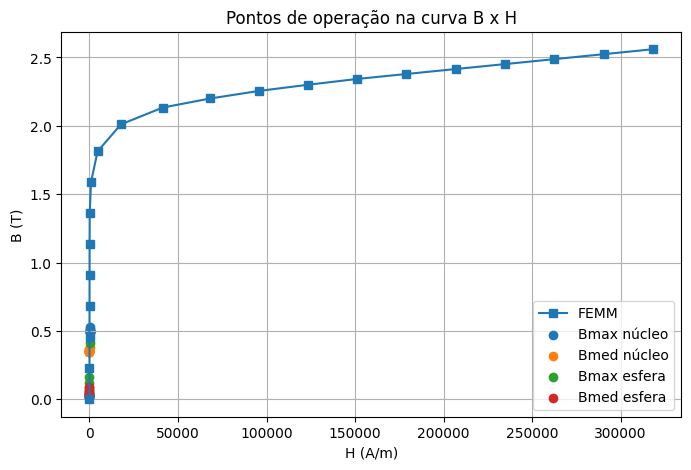

In [35]:
# Curva B x H no mesmo estilo visual da curva do professor

plt.figure(figsize=(8, 5))

plt.plot(H_curve, B_curve, marker="s", label="FEMM")

# Pontos de operação obtidos pela curva FEMM
plt.scatter(Hmax_core_femm, Bmax_core_values, label="Bmax núcleo")
plt.scatter(Hmed_core_femm, Bmed_core_values, label="Bmed núcleo")
plt.scatter(Hmax_sph_femm, Bmax_sph_values, label="Bmax esfera")
plt.scatter(Hmed_sph_femm, Bmed_sph_values, label="Bmed esfera")

plt.xlabel("H (A/m)")
plt.ylabel("B (T)")
plt.title("Pontos de operação na curva B x H")
plt.grid(True)
plt.legend()

plt.show()

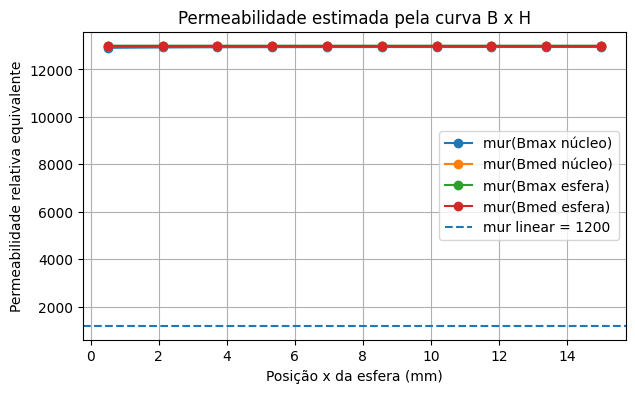

In [36]:
plt.figure(figsize=(7, 4))

plt.plot(x_values * 1e3, mur_max_core, marker="o", label="mur(Bmax núcleo)")
plt.plot(x_values * 1e3, mur_med_core, marker="o", label="mur(Bmed núcleo)")
plt.plot(x_values * 1e3, mur_max_sph, marker="o", label="mur(Bmax esfera)")
plt.plot(x_values * 1e3, mur_med_sph, marker="o", label="mur(Bmed esfera)")

plt.axhline(1200, linestyle="--", label="mur linear = 1200")

plt.xlabel("Posição x da esfera (mm)")
plt.ylabel("Permeabilidade relativa equivalente")
plt.title("Permeabilidade estimada pela curva B x H")
plt.grid(True)
plt.legend()

plt.show()